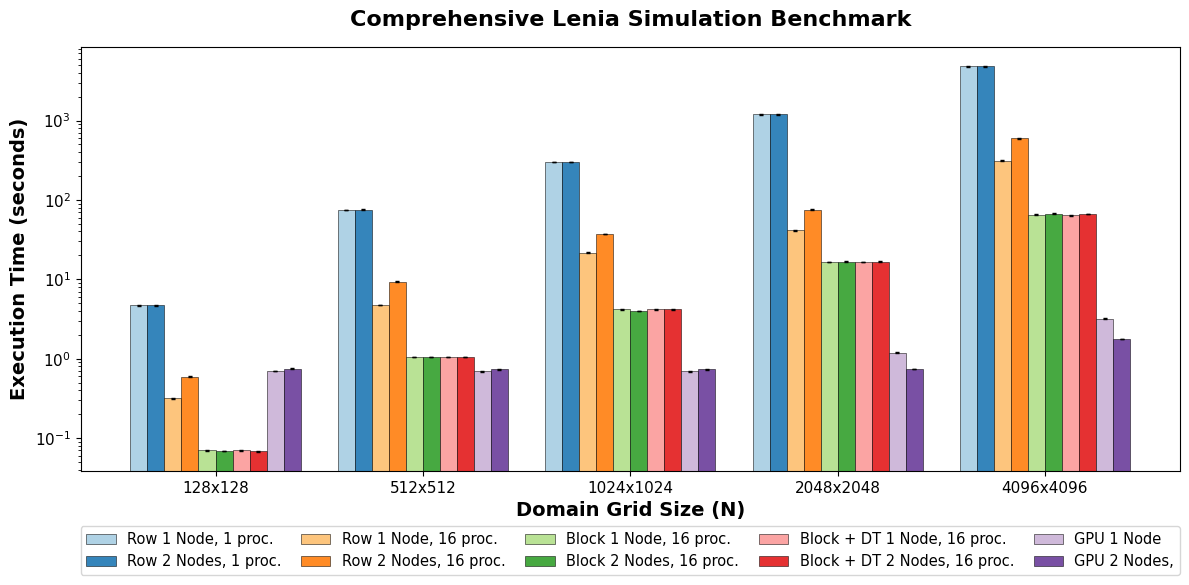

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Dataset configurations
data = {
    128: {
        'row_1proc_1node': (4.6758, 0.0450),
        'row_1proc_2nodes': (4.6991, 0.0450),
        'row_16procs_1node': (0.3156, 0.0032),
        'row_16procs_2nodes': (0.5927, 0.0062),
        'block_notype_16procs_1node': (0.0701, 0.0007),
        'block_notype_16procs_2nodes': (0.0685, 0.0008),
        'block_16procs_1node': (0.0702, 0.0007),
        'block_16procs_2nodes': (0.0681, 0.0007),
        'gpu_1gpu_1node': (0.7003, 0.0070),
        'gpu_2gpus_1node': (0.7491, 0.0075)
    },
    512: {
        'row_1proc_1node': (74.8057, 0.6850),
        'row_1proc_2nodes': (75.0867, 0.6850),
        'row_16procs_1node': (4.7344, 0.0450),
        'row_16procs_2nodes': (9.3257, 0.0920),
        'block_notype_16procs_1node': (1.0508, 0.0095),
        'block_notype_16procs_2nodes': (1.0494, 0.0110),
        'block_16procs_1node': (1.0508, 0.0095),
        'block_16procs_2nodes': (1.0488, 0.0095),
        'gpu_1gpu_1node': (0.6903, 0.0069),
        'gpu_2gpus_1node': (0.7337, 0.0073)
    },
    1024: {
        'row_1proc_1node': (299.4843, 2.9500),
        'row_1proc_2nodes': (300.0451, 2.9500),
        'row_16procs_1node': (21.5592, 0.2100),
        'row_16procs_2nodes': (37.3106, 0.3850),
        'block_notype_16procs_1node': (4.1793, 0.0420),
        'block_notype_16procs_2nodes': (3.9783, 0.0420),
        'block_16procs_1node': (4.1758, 0.0420),
        'block_16procs_2nodes': (4.1790, 0.0480),
        'gpu_1gpu_1node': (0.6904, 0.0069),
        'gpu_2gpus_1node': (0.7355, 0.0074)
    },
    2048: {
        'row_1proc_1node': (1198.5000, 12.0000),
        'row_1proc_2nodes': (1199.8165, 12.0000),
        'row_16procs_1node': (41.2200, 0.4500),
        'row_16procs_2nodes': (74.9744, 0.7500),
        'block_notype_16procs_1node': (16.5500, 0.1600),
        'block_notype_16procs_2nodes': (16.6611, 0.1600),
        'block_16procs_1node': (16.5100, 0.1600),
        'block_16procs_2nodes': (16.6825, 0.1600),
        'gpu_1gpu_1node': (1.1909, 0.0119),
        'gpu_2gpus_1node': (0.7395, 0.0074)
    },
    4096: {
        'row_1proc_1node': (4799.4436, 48.0000),
        'row_1proc_2nodes': (4810.0745, 48.0000),
        'row_16procs_1node': (312.4500, 3.2000),
        'row_16procs_2nodes': (598.8781, 6.0000),
        'block_notype_16procs_1node': (65.1200, 0.6500),
        'block_notype_16procs_2nodes': (67.3140, 0.6700),
        'block_16procs_1node': (64.2100, 0.6500),
        'block_16procs_2nodes': (66.5960, 0.6600),
        'gpu_1gpu_1node': (3.1787, 0.0318),
        'gpu_2gpus_1node': (1.7635, 0.0176)
    }
}

grid_sizes = sorted(list(data.keys()))

ver_keys = [
    'row_1proc_1node', 'row_1proc_2nodes',
    'row_16procs_1node', 'row_16procs_2nodes', 
    'block_notype_16procs_1node', 'block_notype_16procs_2nodes',
    'block_16procs_1node', 'block_16procs_2nodes',
    'gpu_1gpu_1node', 'gpu_2gpus_1node'
]

# Labels mapping
label_mapping = {
    'row_1proc_1node': 'Row 1 Node, 1 proc.',
    'row_16procs_1node': 'Row 1 Node, 16 proc.',
    'block_notype_16procs_1node': 'Block 1 Node, 16 proc.',
    'block_16procs_1node': 'Block + DT 1 Node, 16 proc.',
    'gpu_1gpu_1node': 'GPU 1 Node',

    'row_1proc_2nodes': 'Row 2 Nodes, 1 proc.',
    'row_16procs_2nodes': 'Row 2 Nodes, 16 proc.',
    'block_notype_16procs_2nodes': 'Block 2 Nodes, 16 proc.',
    'block_16procs_2nodes': 'Block + DT 2 Nodes, 16 proc.',
    'gpu_2gpus_1node': 'GPU 2 Nodes,'
}

# 5 distinct color families (Light and dark shades)
color_mapping = {
    'row_1proc_1node': '#a6cee3',
    'row_1proc_2nodes': '#1f78b4',
    'row_16procs_1node': '#fdbf6f',
    'row_16procs_2nodes': '#ff7f0e',
    'block_notype_16procs_1node': '#b2df8a',
    'block_notype_16procs_2nodes': '#33a02c',
    'block_16procs_1node': '#fb9a99',
    'block_16procs_2nodes': '#e31a1c',
    'gpu_1gpu_1node': '#cab2d6',
    'gpu_2gpus_1node': '#6a3d9a'
}

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.082
indices = np.arange(len(grid_sizes))

handles_dict = {}

# Plot the configuration bars
for i, key in enumerate(ver_keys):
    times = [data[grid][key][0] for grid in grid_sizes]
    stds = [data[grid][key][1] for grid in grid_sizes]
    pos = [idx + (i - len(ver_keys)/2) * bar_width + bar_width/2 for idx in indices]
    
    container = ax.bar(pos, times, bar_width, yerr=stds, 
                       color=color_mapping[key], capsize=1.5, alpha=0.90, edgecolor='black', linewidth=0.4)
    handles_dict[key] = container

# Axes styling
ax.set_yscale('log')
ax.set_xticks(indices)
ax.set_xticklabels([f"{g}x{g}" for g in grid_sizes])
ax.set_xlabel('Domain Grid Size (N)', fontsize=14, fontweight='bold')
ax.set_ylabel('Execution Time (seconds)', fontsize=14, fontweight='bold')
ax.tick_params(labelsize=11)
#ax.grid(True, which="both", ls="--", alpha=0.3)

row1_keys = ['row_1proc_1node', 'row_16procs_1node', 'block_notype_16procs_1node', 'block_16procs_1node', 'gpu_1gpu_1node']
row2_keys = ['row_1proc_2nodes', 'row_16procs_2nodes', 'block_notype_16procs_2nodes', 'block_16procs_2nodes', 'gpu_2gpus_1node']

# --- Interweaving the row1 and row2 keys here ---
reordered_keys = [val for pair in zip(row1_keys, row2_keys) for val in pair]
reordered_handles = [handles_dict[k] for k in reordered_keys]
reordered_labels = [label_mapping[k] for k in reordered_keys]

# Apply to legend
ax.legend(
    reordered_handles, 
    reordered_labels,
    loc='upper left',
    bbox_to_anchor=(0.0, -0.23, 1.0, 0.1),
    mode='expand',
    ncol=5,
    fontsize=10.5,
    borderaxespad=0.0
)

plt.title('Comprehensive Lenia Simulation Benchmark', fontsize=16, pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig('lenia_interleaved_legend.png', dpi=300, bbox_inches='tight')

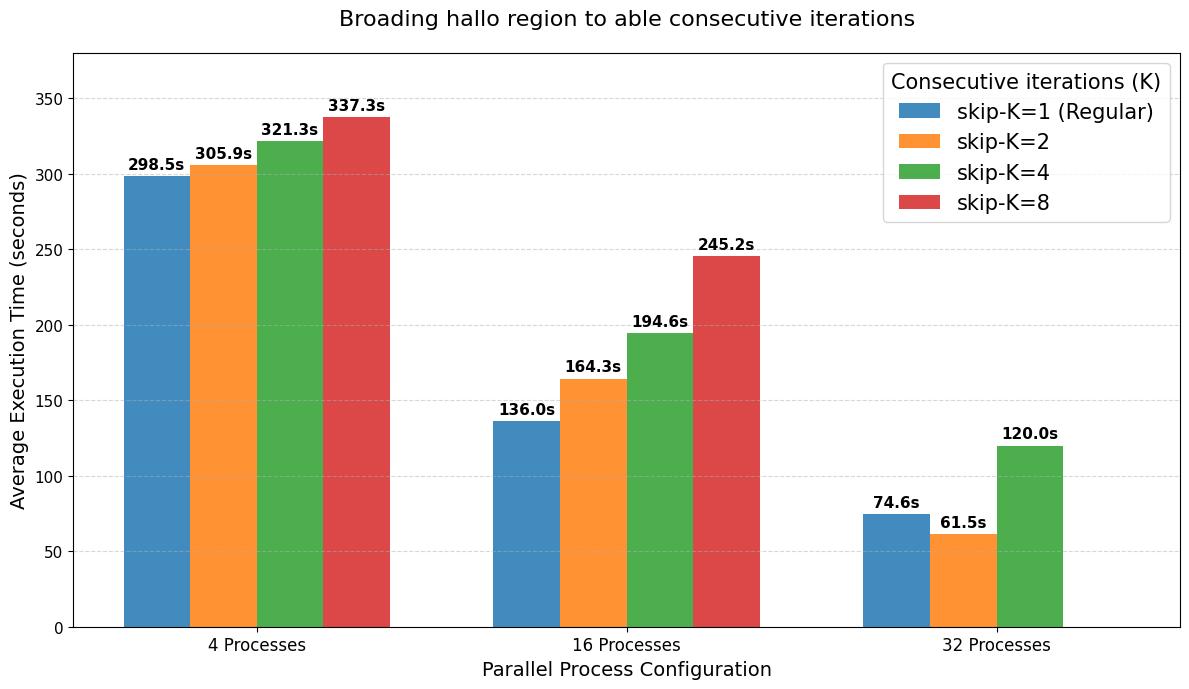

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Data Vectors from Benchmarking Logs
processes = ['4 Processes', '16 Processes', '32 Processes']
skip_keys = ['K=1', 'K=2', 'K=4', 'K=8']

# Storing run times indexed by their skip factor K
times = {
    'K=1': [298.5497, 135.9696, 74.5904],
    'K=2': [305.9024, 164.2544, 61.5078],
    'K=4': [321.2715, 194.6469, 119.9721],
    'K=8': [337.3479, 245.2348, 0.0]       # Note: K=8 was not run for 32 processes
}

# 2. Layout Coordinate Configuration
x = np.arange(len(processes))  # Base tick coordinates
width = 0.18                  # Bar widths within clusters

fig, ax = plt.subplots(figsize=(12, 7))

# 3. Plotting Group Clusters side-by-side using deliberate x offsets
rects1 = ax.bar(x - 1.5*width, times['K=1'], width, label='skip-K=1 (Regular)', alpha=0.85, color='#1f77b4')
rects2 = ax.bar(x - 0.5*width, times['K=2'], width, label='skip-K=2', alpha=0.85, color='#ff7f0e')
rects3 = ax.bar(x + 0.5*width, times['K=4'], width, label='skip-K=4', alpha=0.85, color='#2ca02c')
rects4 = ax.bar(x + 1.5*width, times['K=8'], width, label='skip-K=8', alpha=0.85, color='#d62728')

# 4. Helper Function to Overlay Value Labels onto Each Bar
def add_value_labels(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:  # Avoid putting labels over missing data points
            ax.annotate(f'{height:.1f}s',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 point vertical buffer
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=11, fontweight='bold')

add_value_labels(rects1)
add_value_labels(rects2)
add_value_labels(rects3)
add_value_labels(rects4)

# 5. Scientific Styling and Canvas Cleanliness Rules
ax.set_ylabel('Average Execution Time (seconds)', fontsize=14)
ax.set_xlabel('Parallel Process Configuration', fontsize=14)
ax.set_title('Broading hallo region to able consecutive iterations', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(processes, fontsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.grid(True, axis='y', ls='--', alpha=0.5)
ax.set_ylim(0, 380)  # Ceiling extension to leave vertical room for values text

# 6. Legend Settings
ax.legend(title='Consecutive iterations (K)', title_fontsize=15, fontsize=15, loc='upper right')

plt.tight_layout()
plt.savefig('lenia_skip_k_benchmark.png', dpi=300)